In [ ]:
import pandas as pd
import numpy as np
import re
import streamlit as st
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv("Dataset_task 6.csv", sep=';',decimal=',')

In [3]:
df.head()

,customer_id,age,annual_income_eur,employment_years,credit_score,existing_debt_eur,loan_amount_eur,loan_term_months,monthly_payment_eur,late_payments_12m,debt_to_income_ratio,home_ownership,loan_purpose,default
0,CUST-0001,22,76.469,4,605,1.322,37.438,60,"685,04",4,"50,7%",Own,Personal,1
1,CUST-0002,33,53.617,4,791,12.729,20.489,12,"1.905,34",0,"62,0%",Rent,Personal,0
2,CUST-0003,21,32.057,3,579,2.513,30.744,60,"539,83",0,"95,0%",Rent,Personal,0
3,CUST-0004,40,22.474,7,758,17.292,20.743,12,"1.894,75",0,"95,0%",Own,Education,1
4,CUST-0005,51,81.195,2,585,2.055,14.588,60,"269,66",1,"20,5%",Mortgage,Business,0


In [4]:
df.dtypes

customer_id               str
age                     int64
annual_income_eur         str
employment_years        int64
credit_score            int64
existing_debt_eur         str
loan_amount_eur           str
loan_term_months        int64
monthly_payment_eur       str
late_payments_12m       int64
debt_to_income_ratio      str
home_ownership            str
loan_purpose              str
default                 int64
dtype: object

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   customer_id           300 non-null    str  
 1   age                   300 non-null    int64
 2   annual_income_eur     300 non-null    str  
 3   employment_years      300 non-null    int64
 4   credit_score          300 non-null    int64
 5   existing_debt_eur     300 non-null    str  
 6   loan_amount_eur       300 non-null    str  
 7   loan_term_months      300 non-null    int64
 8   monthly_payment_eur   300 non-null    str  
 9   late_payments_12m     300 non-null    int64
 10  debt_to_income_ratio  300 non-null    str  
 11  home_ownership        300 non-null    str  
 12  loan_purpose          300 non-null    str  
 13  default               300 non-null    int64
dtypes: int64(6), str(8)
memory usage: 48.1 KB


In [6]:
isnull_count = df.isnull().sum()
print("Number of Nulls:", isnull_count)

# Total Nulls in Dataset
Total_isnull_count = isnull_count.sum()

print("Total Nulls:", Total_isnull_count)

Number of Nulls: customer_id             0
age                     0
annual_income_eur       0
employment_years        0
credit_score            0
existing_debt_eur       0
loan_amount_eur         0
loan_term_months        0
monthly_payment_eur     0
late_payments_12m       0
debt_to_income_ratio    0
home_ownership          0
loan_purpose            0
default                 0
dtype: int64
Total Nulls: 0


In [7]:
# convert numeric-looking strings to floats
for col in ['annual_income_eur', 'existing_debt_eur', 'loan_amount_eur',
            'monthly_payment_eur', 'debt_to_income_ratio']:
    df[col] = (
        df[col]
        .str.replace('.', '')
        .str.replace(',', '.')        # replace comma with dot for decimals
        .str.replace('%', '')         # remove percent signs if any
        .astype(float)                # convert to float
    )


In [8]:
df.dtypes

customer_id                 str
age                       int64
annual_income_eur       float64
employment_years          int64
credit_score              int64
existing_debt_eur       float64
loan_amount_eur         float64
loan_term_months          int64
monthly_payment_eur     float64
late_payments_12m         int64
debt_to_income_ratio    float64
home_ownership              str
loan_purpose                str
default                   int64
dtype: object

In [9]:
df.head()

,customer_id,age,annual_income_eur,employment_years,credit_score,existing_debt_eur,loan_amount_eur,loan_term_months,monthly_payment_eur,late_payments_12m,debt_to_income_ratio,home_ownership,loan_purpose,default
0,CUST-0001,22,76469.0,4,605,1322.0,37438.0,60,685.04,4,50.7,Own,Personal,1
1,CUST-0002,33,53617.0,4,791,12729.0,20489.0,12,1905.34,0,62.0,Rent,Personal,0
2,CUST-0003,21,32057.0,3,579,2513.0,30744.0,60,539.83,0,95.0,Rent,Personal,0
3,CUST-0004,40,22474.0,7,758,17292.0,20743.0,12,1894.75,0,95.0,Own,Education,1
4,CUST-0005,51,81195.0,2,585,2055.0,14588.0,60,269.66,1,20.5,Mortgage,Business,0


In [12]:
# Unusual observations
df.describe()

,age,annual_income_eur,employment_years,credit_score,existing_debt_eur,loan_amount_eur,loan_term_months,monthly_payment_eur,late_payments_12m,debt_to_income_ratio,default
count,300.000000,300.00000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,46.276667,50073.46000,6.786667,666.813333,12036.356667,18183.820000,36.040000,767.998900,1.520000,61.484333,0.210000
std,13.981837,18285.17686,4.411276,81.924052,8777.506212,9222.339429,17.238007,665.119088,1.391421,26.115179,0.407989
min,21.000000,18000.00000,0.000000,461.000000,0.000000,2500.000000,12.000000,43.730000,0.000000,4.900000,0.000000
25%,34.750000,36448.75000,3.000000,605.000000,5410.250000,11661.500000,24.000000,306.580000,0.000000,41.475000,0.000000
50%,48.000000,49862.00000,7.000000,661.500000,11236.000000,18660.000000,36.000000,553.140000,1.000000,59.700000,0.000000
75%,58.000000,63069.50000,10.000000,724.000000,17635.000000,25315.250000,48.000000,985.780000,2.000000,87.775000,0.000000
max,69.000000,103356.00000,21.000000,835.000000,49410.000000,42593.000000,60.000000,3306.040000,6.000000,95.000000,1.000000


In [13]:
df['default'].value_counts(normalize=True)

default
0    0.79
1    0.21
Name: proportion, dtype: float64

In [14]:
df.groupby('default')[['annual_income_eur', 'credit_score', 'existing_debt_eur',
                       'loan_amount_eur', 'loan_term_months', 'late_payments_12m']].mean()


,annual_income_eur,credit_score,existing_debt_eur,loan_amount_eur,loan_term_months,late_payments_12m
default,,,,,,
0,50018.333333,674.607595,11596.375527,17694.050633,36.101266,1.367089
1,50280.841270,637.492063,13691.523810,20026.285714,35.809524,2.095238


<Axes: xlabel='credit_score', ylabel='Count'>

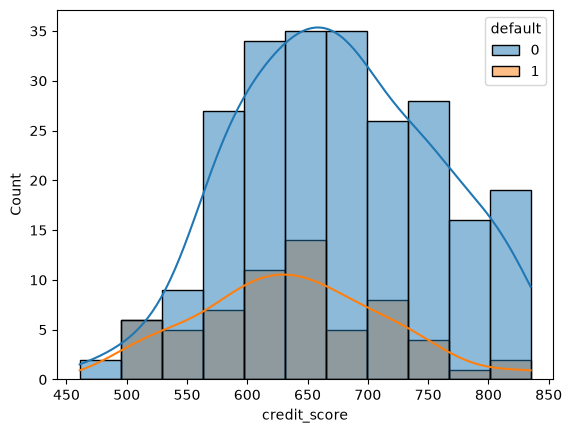

In [15]:
sns.histplot(data=df, x='credit_score', hue='default', kde=True)


<Axes: xlabel='default', ylabel='annual_income_eur'>

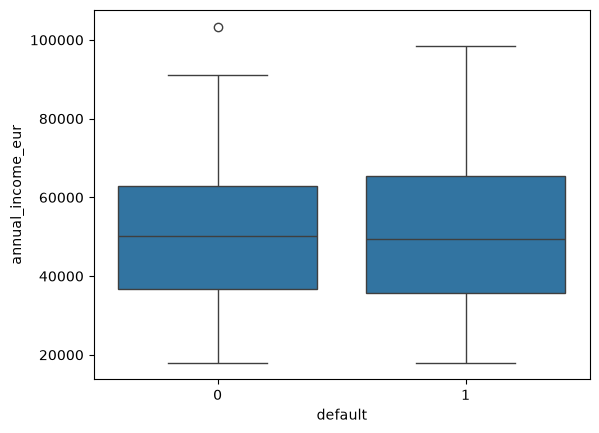

In [16]:
sns.boxplot(data=df, x='default', y='annual_income_eur')


In [23]:
df_clean = df.drop(columns=["customer_id"], inplace=True)

KeyError: "['customer_id'] not found in axis"

In [26]:
df.head()

,age,annual_income_eur,employment_years,credit_score,existing_debt_eur,loan_amount_eur,loan_term_months,monthly_payment_eur,late_payments_12m,debt_to_income_ratio,home_ownership,loan_purpose,default
0,22,76469.0,4,605,1322.0,37438.0,60,685.04,4,50.7,Own,Personal,1
1,33,53617.0,4,791,12729.0,20489.0,12,1905.34,0,62.0,Rent,Personal,0
2,21,32057.0,3,579,2513.0,30744.0,60,539.83,0,95.0,Rent,Personal,0
3,40,22474.0,7,758,17292.0,20743.0,12,1894.75,0,95.0,Own,Education,1
4,51,81195.0,2,585,2055.0,14588.0,60,269.66,1,20.5,Mortgage,Business,0


In [30]:
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_columns = df.select_dtypes(include=['str']).columns.tolist()  

<Axes: xlabel='loan_purpose', ylabel='count'>

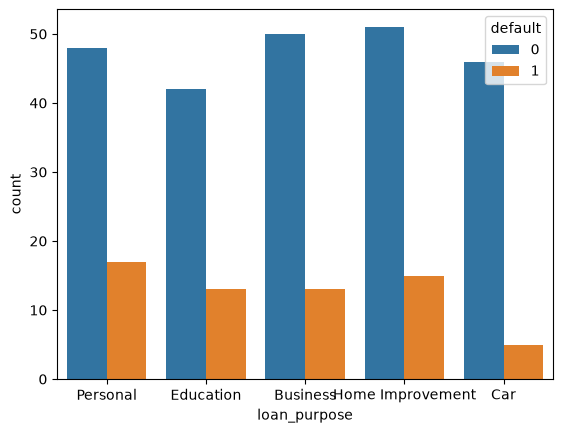

In [33]:
sns.countplot(data=df, x='loan_purpose', hue='default')


<Axes: xlabel='home_ownership', ylabel='count'>

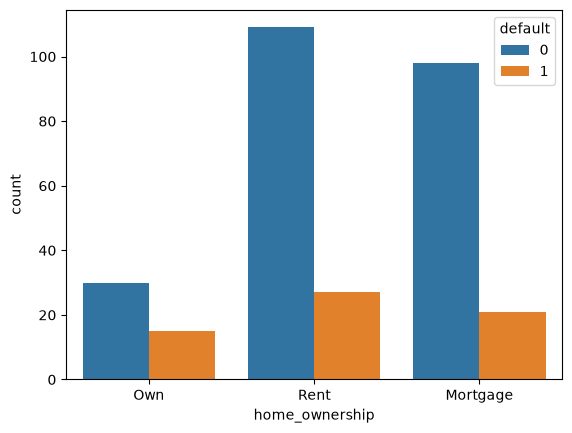

In [34]:
sns.countplot(data=df, x='home_ownership', hue='default')

In [35]:
df_encoded = df.copy()

In [42]:
from sklearn.preprocessing import OneHotEncoder

# Initialize encoder
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

# Fit and transform categorical columns
encoded_cols = ohe.fit_transform(df[categorical_columns])

# Create a DataFrame with generated column names
encoded_df = pd.DataFrame(encoded_cols, columns=ohe.get_feature_names_out(categorical_columns))

# Merge back with original DataFrame (dropping original text columns)
final_df = pd.concat(
    [df.drop(columns=categorical_columns), encoded_df],
    axis=1
)

In [43]:
final_df.head()

,age,annual_income_eur,employment_years,credit_score,existing_debt_eur,loan_amount_eur,loan_term_months,monthly_payment_eur,late_payments_12m,debt_to_income_ratio,default,home_ownership_Own,home_ownership_Rent,loan_purpose_Car,loan_purpose_Education,loan_purpose_Home Improvement,loan_purpose_Personal
0,22,76469.0,4,605,1322.0,37438.0,60,685.04,4,50.7,1,1.0,0.0,0.0,0.0,0.0,1.0
1,33,53617.0,4,791,12729.0,20489.0,12,1905.34,0,62.0,0,0.0,1.0,0.0,0.0,0.0,1.0
2,21,32057.0,3,579,2513.0,30744.0,60,539.83,0,95.0,0,0.0,1.0,0.0,0.0,0.0,1.0
3,40,22474.0,7,758,17292.0,20743.0,12,1894.75,0,95.0,1,1.0,0.0,0.0,1.0,0.0,0.0
4,51,81195.0,2,585,2055.0,14588.0,60,269.66,1,20.5,0,0.0,0.0,0.0,0.0,0.0,0.0


In [44]:
from sklearn.preprocessing import StandardScaler
#scale numerical values
scaler = StandardScaler()
num_cols = ['annual_income_eur','existing_debt_eur','loan_amount_eur',
            'monthly_payment_eur','credit_score','debt_to_income_ratio']
final_df[num_cols] = scaler.fit_transform(final_df[num_cols])


In [58]:
final_df.head()

,age,annual_income_eur,employment_years,credit_score,existing_debt_eur,loan_amount_eur,loan_term_months,monthly_payment_eur,late_payments_12m,debt_to_income_ratio,default,home_ownership_Own,home_ownership_Rent,loan_purpose_Car,loan_purpose_Education,loan_purpose_Home Improvement,loan_purpose_Personal
0,22,1.445960,4,-0.755781,-1.222700,2.091264,60,-0.124936,4,-0.413643,1,1.0,0.0,0.0,0.0,0.0,1.0
1,33,0.194117,4,1.518408,0.079043,0.250374,12,1.712838,0,0.019779,0,0.0,1.0,0.0,0.0,0.0,1.0
2,21,-0.986950,3,-1.073678,-1.086786,1.364205,60,-0.343623,0,1.285523,0,0.0,1.0,0.0,0.0,0.0,1.0
3,40,-1.511912,7,1.114923,0.599763,0.277962,12,1.696890,0,1.285523,1,1.0,0.0,0.0,1.0,0.0,0.0
4,51,1.704853,2,-1.000317,-1.139052,-0.390555,60,-0.750500,1,-1.571990,0,0.0,0.0,0.0,0.0,0.0,0.0


In [47]:
X = final_df.drop('default', axis=1)
y = final_df['default']


In [48]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [45]:
from sklearn.metrics import (
                             roc_auc_score, roc_curve)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [53]:
# Logistic Regression
lr = LogisticRegression(class_weight='balanced', max_iter=1000)
lr.fit(X_train, y_train)

# Random Forest
rf = RandomForestClassifier(class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.72      0.76        47
           1       0.24      0.31      0.27        13

    accuracy                           0.63        60
   macro avg       0.51      0.52      0.51        60
weighted avg       0.67      0.63      0.65        60



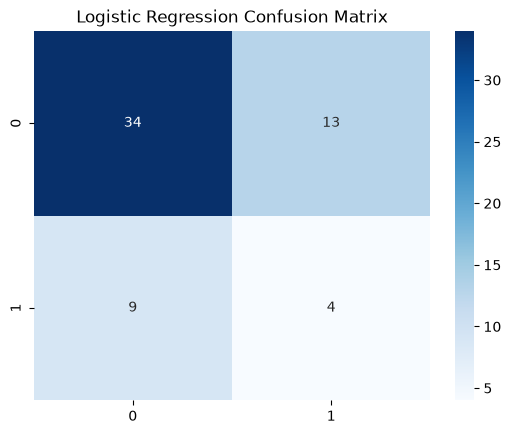

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.87      0.81        47
           1       0.00      0.00      0.00        13

    accuracy                           0.68        60
   macro avg       0.38      0.44      0.41        60
weighted avg       0.59      0.68      0.64        60



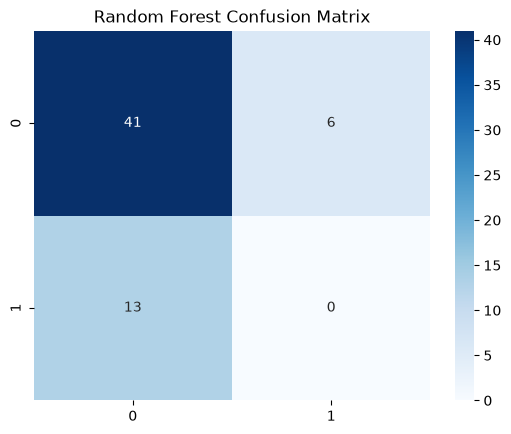

In [54]:
# predictions
# Logistic Regression
y_pred_lr = lr.predict(X_test)

# classification report
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr))

#confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

# Random Forest
y_pred_rf = rf.predict(X_test)
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

#confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.show()

ROC-AUC Score for Logistic Regression: 0.54
PR-AUC Score: 0.23


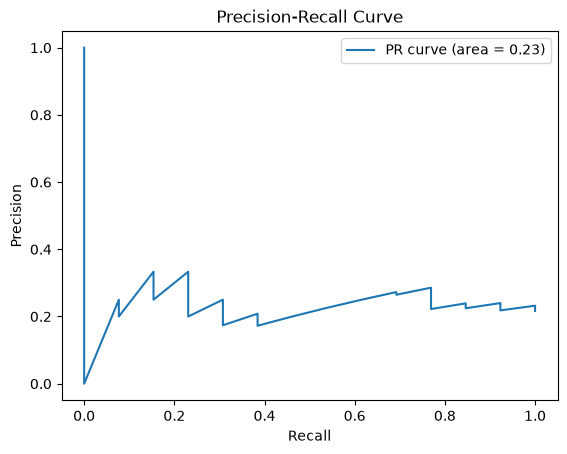

In [55]:
from sklearn.metrics import precision_recall_curve, auc
# evaluating model probabilities for class 1
y_pred_prob_lr = lr.predict_proba(X_test)[:,1]

# compute roc-auc
roc_auc = roc_auc_score(y_test, y_pred_prob_lr)
print(f"ROC-AUC Score for Logistic Regression: {roc_auc:.2f}")

# compute precision-recall curve and pr-auc
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob_lr)
pr_auc_lr = auc(recall, precision)
print(f"PR-AUC Score: {pr_auc_lr:.2f}")

# Plot Precision-Recall Curve
plt.figure()
plt.plot(recall, precision, label=f'PR curve (area = {pr_auc_lr:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="upper right")
plt.show()

ROC-AUC Score for Random Forest: 0.54
PR-AUC Score: 0.21


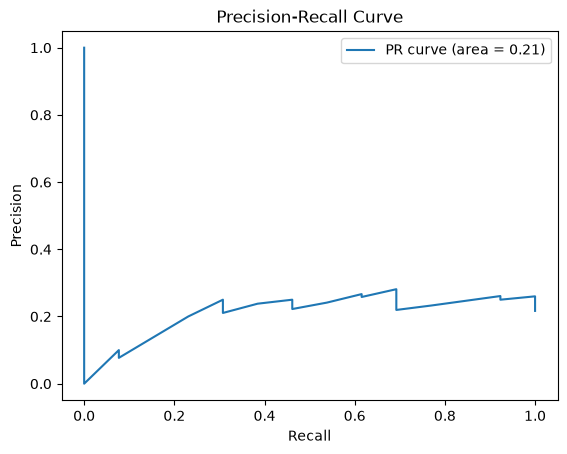

In [56]:
# evaluating model probabilities for class 1
y_pred_prob_rf = rf.predict_proba(X_test)[:,1]

# compute roc-auc
roc_auc = roc_auc_score(y_test, y_pred_prob_rf)
print(f"ROC-AUC Score for Random Forest: {roc_auc:.2f}")

# compute precision-recall curve and pr-auc
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob_rf)
pr_auc_rf = auc(recall, precision)
print(f"PR-AUC Score: {pr_auc_rf:.2f}")

# Plot Precision-Recall Curve
plt.figure()
plt.plot(recall, precision, label=f'PR curve (area = {pr_auc_rf:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="upper right")
plt.show()

In [57]:
# Select your scaled numerical columns
scaled_cols = ['annual_income_eur', 'existing_debt_eur', 'loan_amount_eur', 'monthly_payment_eur', 'credit_score', 'debt_to_income_ratio']

# View summary statistics
stats = df[scaled_cols].describe().T[['mean', 'std', 'min', '50%', 'max']].round(3)
print(stats)

                           mean        std       min       50%        max
annual_income_eur     50073.460  18285.177  18000.00  49862.00  103356.00
existing_debt_eur     12036.357   8777.506      0.00  11236.00   49410.00
loan_amount_eur       18183.820   9222.339   2500.00  18660.00   42593.00
monthly_payment_eur     767.999    665.119     43.73    553.14    3306.04
credit_score            666.813     81.924    461.00    661.50     835.00
debt_to_income_ratio     61.484     26.115      4.90     59.70      95.00
